# What "Learning from Data" Actually Means — Before Any Model

Companion notebook for Act 1, Article 1 of the ML series.  
Runs standalone — no dependencies on other folders.

Article link: *(add when published)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pinned URLs — same data the article used
DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"

## Getting the Data

In [2]:
df = pd.read_parquet(DATA_URL)

print(df.shape)
print(df.dtypes)
print(df.head(3))

(2964624, 19)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36        

## What the Raw Data Actually Looks Like

In [16]:
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

In [17]:
cols = ["passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount"]
print(df[cols].describe())

       passenger_count  trip_distance  fare_amount   tip_amount  total_amount
count     2,824,462.00   2,964,624.00 2,964,624.00 2,964,624.00  2,964,624.00
mean              1.34           3.65        18.18         3.34         26.80
std               0.85         225.46        18.95         3.90         23.39
min               0.00           0.00      -899.00       -80.00       -900.00
25%               1.00           1.00         8.60         1.00         15.38
50%               1.00           1.68        12.80         2.70         20.10
75%               1.00           3.11        20.50         4.12         28.56
max               9.00     312,722.30     5,000.00       428.00      5,000.00


In [18]:
df_feat["avg_speed_mph"].describe()

count   2,644,424.00
mean           11.38
std             6.53
min             0.01
25%             7.36
50%             9.61
75%            12.97
max            80.00
Name: avg_speed_mph, dtype: float64

In [19]:
# Missing values — notice the identical percentage across five columns
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0].sort_values(ascending=False))

passenger_count        4.73
RatecodeID             4.73
store_and_fwd_flag     4.73
congestion_surcharge   4.73
Airport_fee            4.73
dtype: float64


## Cleaning With Intent, Not Habit

In [5]:
def clean_trips(df):
    df = df[df["fare_amount"] > 0]
    df = df[df["tip_amount"] >= 0]
    df = df[df["passenger_count"] >= 1]
    df = df[df["passenger_count"] <= 5]
    df = df[df["trip_distance"] > 0]
    df = df[df["trip_distance"] <= 50]
    df = df[df["fare_amount"] >= 3.0]
    df = df[df["fare_amount"] <= 200]

    df["trip_duration_min"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    df = df[df["trip_duration_min"] > 1]
    df = df[df["trip_duration_min"] <= 120]
    df = df[df["RatecodeID"].isin([1, 2])]
    return df.reset_index(drop=True)


df_clean = clean_trips(df)

print(f"Original rows : {len(df):,}")
print(f"After cleaning: {len(df_clean):,}")
print(f"Removed       : {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.1f}%)")

Original rows : 2,964,624
After cleaning: 2,644,424
Removed       : 320,200 (10.8%)


## Feature Engineering — Where the Real Work Is

In [22]:
def engineer_features(df):
    dt = df["tpep_pickup_datetime"]

    df["pickup_hour"]      = dt.dt.hour
    df["pickup_dayofweek"] = dt.dt.dayofweek
    df["pickup_month"]     = dt.dt.month
    df["is_weekend"]       = (dt.dt.dayofweek >= 5).astype(int)
    df["is_rush_hour"]     = (
        ((dt.dt.hour >= 7)  & (dt.dt.hour <= 9)) |
        ((dt.dt.hour >= 16) & (dt.dt.hour <= 19))
    ).astype(int)
    df["is_late_night"]    = ((dt.dt.hour >= 22) | (dt.dt.hour <= 5)).astype(int)

    df["avg_speed_mph"] = (df["trip_distance"] / (df["trip_duration_min"] / 60)).clip(upper=45)
    df["fare_per_mile"]    = (df["fare_amount"] / df["trip_distance"]).clip(upper=50)
    df["is_card_payment"]  = (df["payment_type"] == 1).astype(int)
    df["is_jfk_rate"]      = (df["RatecodeID"] == 2).astype(int)

    return df


df_feat = engineer_features(df_clean)

## The Cash Tip Trap

In [23]:
cash_trips = df_feat[df_feat["payment_type"] == 2]
card_trips  = df_feat[df_feat["payment_type"] == 1]

print(f"Cash trips with tip_amount > 0 : {(cash_trips['tip_amount'] > 0).mean():.2%}")
print(f"Card trips with tip_amount > 0 : {(card_trips['tip_amount'] > 0).mean():.2%}")

# Filter to card payments only
df_model = df_feat[df_feat["is_card_payment"] == 1].copy()
print(f"\nCard payment trips: {len(df_model):,}")

Cash trips with tip_amount > 0 : 0.00%
Card trips with tip_amount > 0 : 96.56%

Card payment trips: 2,207,598


## What the Distributions Are Telling You

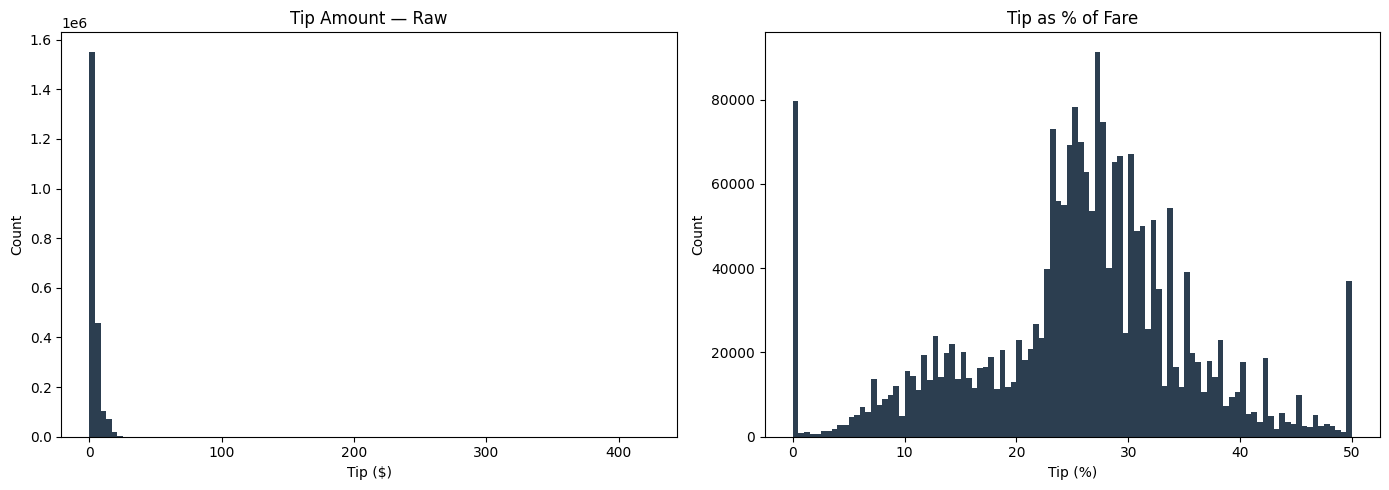

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model["tip_amount"], bins=100, color="#2c3e50", edgecolor="none")
axes[0].set_title("Tip Amount — Raw")
axes[0].set_xlabel("Tip ($)")
axes[0].set_ylabel("Count")

df_model["tip_pct"] = (df_model["tip_amount"] / df_model["fare_amount"] * 100).clip(0, 100)
axes[1].hist(df_model["tip_pct"].clip(0, 50), bins=100, color="#2c3e50", edgecolor="none")
axes[1].set_title("Tip as % of Fare")
axes[1].set_xlabel("Tip (%)")
axes[1].set_ylabel("Count")

plt.tight_layout()

# Save figure
fig.savefig("tip_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

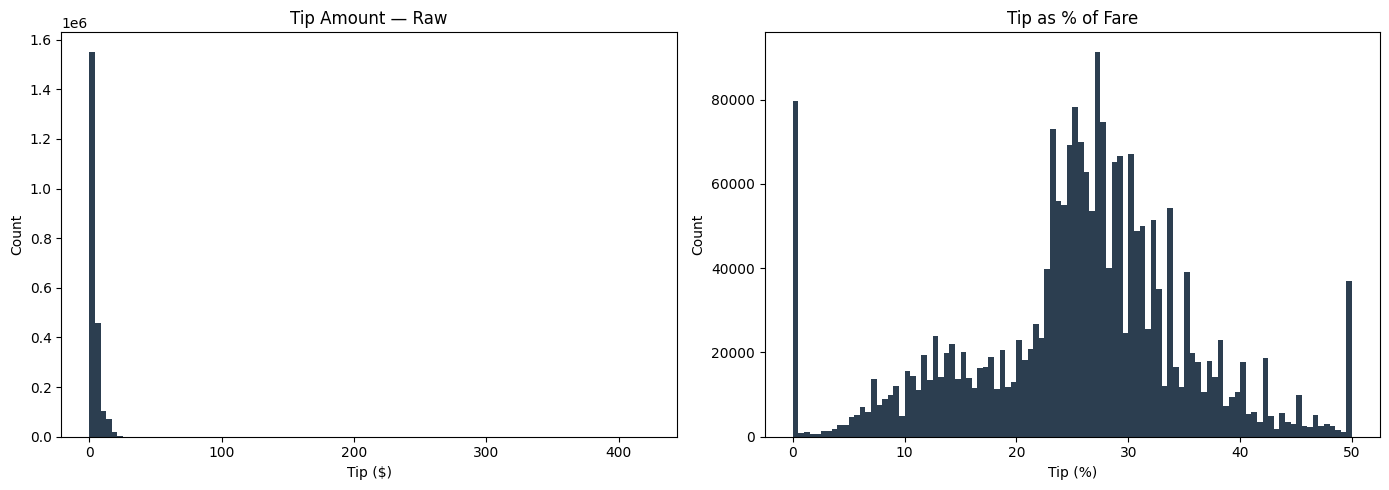

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model["tip_amount"], bins=100, color="#2c3e50", edgecolor="none")
axes[0].set_title("Tip Amount — Raw")
axes[0].set_xlabel("Tip ($)")
axes[0].set_ylabel("Count")

df_model["tip_pct"] = df_model["tip_amount"] / df_model["fare_amount"] * 100
axes[1].hist(df_model["tip_pct"].clip(0, 50), bins=100, color="#2c3e50", edgecolor="none")
axes[1].set_title("Tip as % of Fare")
axes[1].set_xlabel("Tip (%)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [20]:
# The 20% spike
at_20 = ((df_model["tip_pct"] >= 19.5) & (df_model["tip_pct"] <= 20.5)).sum()
print(f"Trips tipping exactly ~20%: {at_20:,} ({at_20/len(df_model):.1%})")

Trips tipping exactly ~20%: 35,928 (1.6%)


## Correlation — and Why Changing the Target Changes Everything

In [10]:
features = [
    "trip_distance", "fare_amount", "pickup_hour",
    "is_weekend", "is_rush_hour", "is_late_night",
    "avg_speed_mph", "fare_per_mile", "trip_duration_min",
    "passenger_count", "is_jfk_rate",
]

print("── Correlation with tip_amount ──")
corr_amt = df_model[features + ["tip_amount"]].corr()["tip_amount"].drop("tip_amount")
print(corr_amt.sort_values(ascending=False))

print("\n── Correlation with tip_pct ──")
corr_pct = df_model[features + ["tip_pct"]].corr()["tip_pct"].drop("tip_pct")
print(corr_pct.sort_values(ascending=False))

── Correlation with tip_amount ──
fare_amount          0.785312
trip_distance        0.767473
trip_duration_min    0.698917
avg_speed_mph        0.538602
is_jfk_rate          0.517967
pickup_hour          0.031315
passenger_count      0.028356
is_late_night        0.012210
is_rush_hour        -0.002544
is_weekend          -0.031317
fare_per_mile       -0.367140
Name: tip_amount, dtype: float64

── Correlation with tip_pct ──
fare_per_mile        0.163012
pickup_hour          0.039606
is_rush_hour         0.039437
is_late_night       -0.009923
passenger_count     -0.011839
is_weekend          -0.027047
is_jfk_rate         -0.085270
avg_speed_mph       -0.099419
trip_distance       -0.184838
fare_amount         -0.217196
trip_duration_min   -0.241608
Name: tip_pct, dtype: float64


## Preparing the Final Feature Set

In [12]:
zones    = pd.read_csv(ZONE_URL)
zone_map = zones.set_index("LocationID")["Borough"].to_dict()
df_model["pickup_borough"]  = df_model["PULocationID"].map(zone_map)
df_model["dropoff_borough"] = df_model["DOLocationID"].map(zone_map)
borough_enc = {b: i for i, b in enumerate(df_model["pickup_borough"].dropna().unique())}
df_model["pickup_borough_enc"]  = df_model["pickup_borough"].map(borough_enc)
df_model["dropoff_borough_enc"] = df_model["dropoff_borough"].map(borough_enc)

MODEL_FEATURES = [
    "trip_distance", "trip_duration_min", "fare_amount",
    "pickup_hour", "pickup_dayofweek", "is_weekend",
    "is_rush_hour", "is_late_night", "avg_speed_mph",
    "fare_per_mile", "passenger_count", "is_jfk_rate",
    "pickup_borough_enc", "dropoff_borough_enc",
]
TARGET = "tip_pct"

df_final = df_model[MODEL_FEATURES + [TARGET, "tpep_pickup_datetime"]].dropna()

print(f"Final dataset shape: {df_final[MODEL_FEATURES + [TARGET]].shape}")
print(df_final[TARGET].describe())

Final dataset shape: (2206085, 15)
count    2.206085e+06
mean     2.582643e+01
std      1.317808e+01
min      0.000000e+00
25%      2.135325e+01
50%      2.644628e+01
75%      3.111111e+01
max      2.348837e+03
Name: tip_pct, dtype: float64


## Train/Test Split — Time-Based

In [13]:
df_final = df_final.sort_values("tpep_pickup_datetime")

# Last 25% of January as test set
cutoff     = df_final["tpep_pickup_datetime"].quantile(0.75)
train_mask = df_final["tpep_pickup_datetime"] <= cutoff

X_train = df_final.loc[ train_mask, MODEL_FEATURES]
X_test  = df_final.loc[~train_mask, MODEL_FEATURES]
y_train = df_final.loc[ train_mask, TARGET]
y_test  = df_final.loc[~train_mask, TARGET]

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print("\nX_train / y_train / X_test / y_test ready.")
print("No model.fit() — that is the next article.")

Training samples : 1,654,565
Test samples     : 551,520

X_train / y_train / X_test / y_test ready.
No model.fit() — that is the next article.


In [26]:
df_model = df_feat[df_feat["is_card_payment"] == 1].copy()

# Create tip_pct here — available to all cells below
df_model["tip_pct"] = (
    df_model["tip_amount"] / df_model["fare_amount"] * 100
).clip(0, 100)

print(f"Card payment trips: {len(df_model):,}")

Card payment trips: 2,207,598


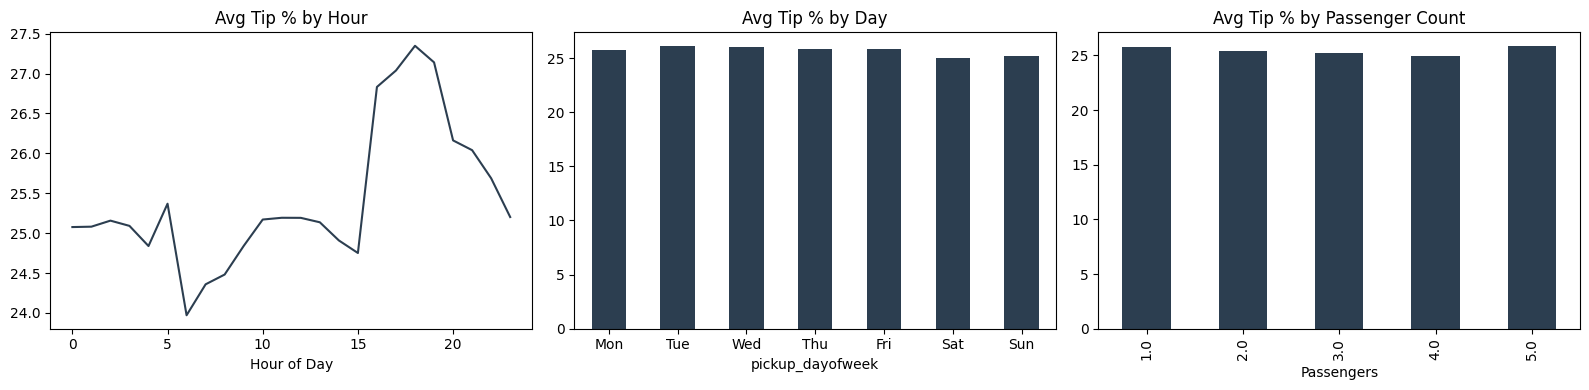

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tip % by hour
df_model.groupby("pickup_hour")["tip_pct"].mean().plot(
    ax=axes[0], color="#2c3e50"
)
axes[0].set_title("Avg Tip % by Hour")
axes[0].set_xlabel("Hour of Day")

# Tip % by day of week
df_model.groupby("pickup_dayofweek")["tip_pct"].mean().plot(
    kind="bar", ax=axes[1], color="#2c3e50"
)
axes[1].set_title("Avg Tip % by Day")
axes[1].set_xticklabels(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0
)

# Tip % by passenger count — already in df_model
df_model.groupby("passenger_count")["tip_pct"].mean().plot(
    kind="bar", ax=axes[2], color="#2c3e50"
)
axes[2].set_title("Avg Tip % by Passenger Count")
axes[2].set_xlabel("Passengers")

plt.tight_layout()
plt.savefig("feature_signal.png", dpi=150)
plt.show()